In [1]:
import sys
import os
import numpy as np

sys.path.append(os.path.abspath("..")) 

import matplotlib.pyplot as plt
import jax
import jax.numpy as jnp
import jax.random as jr
from models.epidemic import SISGraph

key=jr.PRNGKey(42)

In [2]:

G = SISGraph(200)
G.positions()
G.distances()
A = G.random_graphon(key=key)

dt = 0.01
T=5
indexes = jnp.arange(5)
# simulate dynamics
sol = G.simulate(T=T, dt=dt)

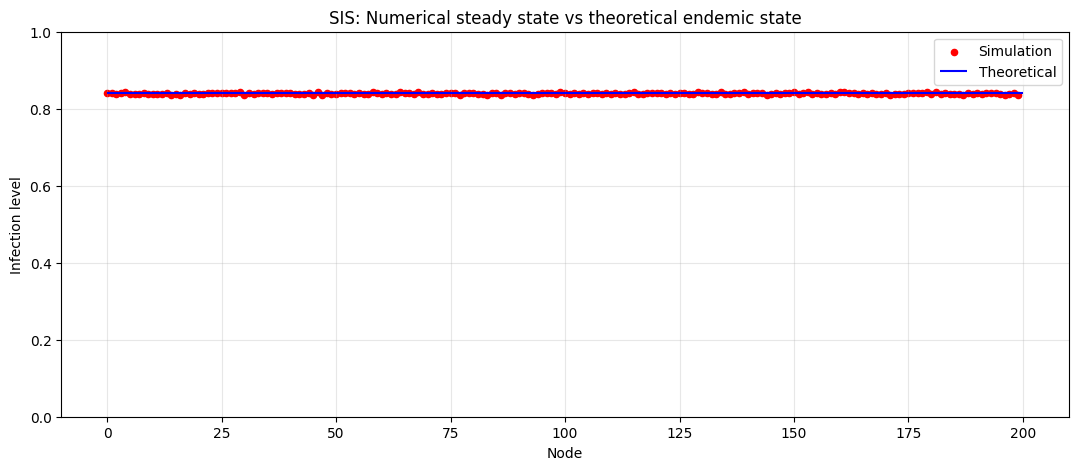

Theoretical endemic u* = 0.8403202891349792
Numerical average = 0.8397332429885864


In [4]:
dx = 2 * jnp.pi / G.n
lambda1 = float(jnp.sum(G.A[0, :])) * dx   
u_theory = float(jnp.clip(1.0 - G.gamma / (G.beta * lambda1), 0.0, 1.0))


nodes = jnp.arange(G.n)

plt.figure(figsize=(13,5))
plt.scatter(nodes, sol.ys[-1], s=20, label="Simulation", color="red")
plt.hlines(u_theory, 0, G.n, color='blue', label="Theoretical")
plt.ylim(0, 1)
plt.title("SIS: Numerical steady state vs theoretical endemic state")
plt.xlabel("Node")
plt.ylabel("Infection level")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

print("Theoretical endemic u* =", u_theory)
print("Numerical average =", float(sol.ys[-1].mean()))


In [5]:
ns = np.linspace(5, 300, 21, dtype=int) # create graphs between 5 and 300 nodes
keys = jr.split(key, len(ns))
Gs = []
As = []
for n, k in zip(ns, keys):
    G = SISGraph(n)
    G.positions()
    G.distances()
    A = G.random_graphon(key=k)
    Gs.append(G)
    As.append(A)


dt = 0.01
T=5
indexes = jnp.arange(5)
sols = []
# simulate dynamics for each graph
for G in Gs:
    sol = G.simulate(T=T, dt=dt)
    sols.append(sol)


In [ ]:
dxs = [2 * jnp.pi / G.n for G in Gs]

lambdas = [float(jnp.sum(G.A[0, :])) * dx  for G, dx in zip(Gs, dxs)]  # any row sum is fine for circulant A


u_nums = [float(sol.ys[-1].mean()) for sol in sols]
u_theorys = [float(jnp.clip(1.0 - G.gamma / (G.beta * lambda1), 0.0, 1.0)) for G, lambda1 in zip(Gs, lambdas)]

differences = []
for u_n, u_t in zip(u_nums, u_theorys):
    differences.append(np.absolute(u_n-u_t))

Theory:  0.8029533624649048  Numerical:  0.815997302532196  Difference:  -0.01304394006729126
Theory:  0.8307443261146545  Numerical:  0.8224070072174072  Difference:  0.008337318897247314
Theory:  0.8366233706474304  Numerical:  0.8345012068748474  Difference:  0.002122163772583008
Theory:  0.838655412197113  Numerical:  0.8396140336990356  Difference:  -0.0009586215019226074
Theory:  0.8384765386581421  Numerical:  0.841053307056427  Difference:  -0.002576768398284912
Theory:  0.8383592367172241  Numerical:  0.8371940851211548  Difference:  0.001165151596069336
Theory:  0.8379198908805847  Numerical:  0.8394059538841248  Difference:  -0.001486063003540039
Theory:  0.8399666547775269  Numerical:  0.8352140188217163  Difference:  0.004752635955810547
Theory:  0.8398658037185669  Numerical:  0.839795708656311  Difference:  7.009506225585938e-05
Theory:  0.8391529321670532  Numerical:  0.839867889881134  Difference:  -0.0007149577140808105
Theory:  0.8396360874176025  Numerical:  0.84054

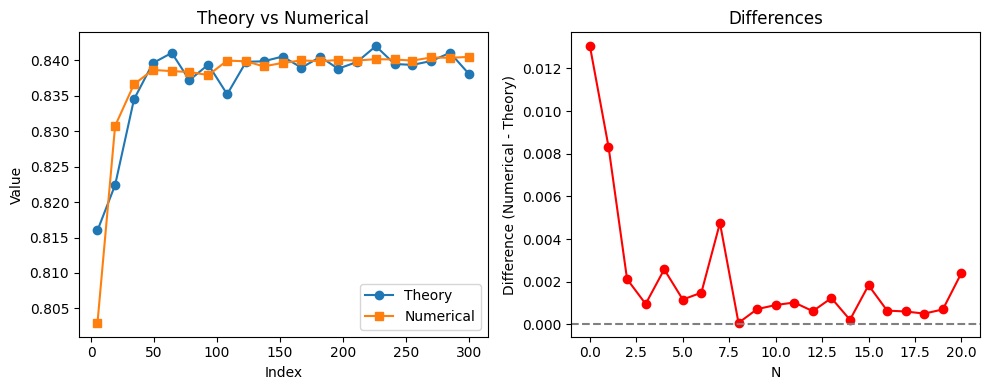

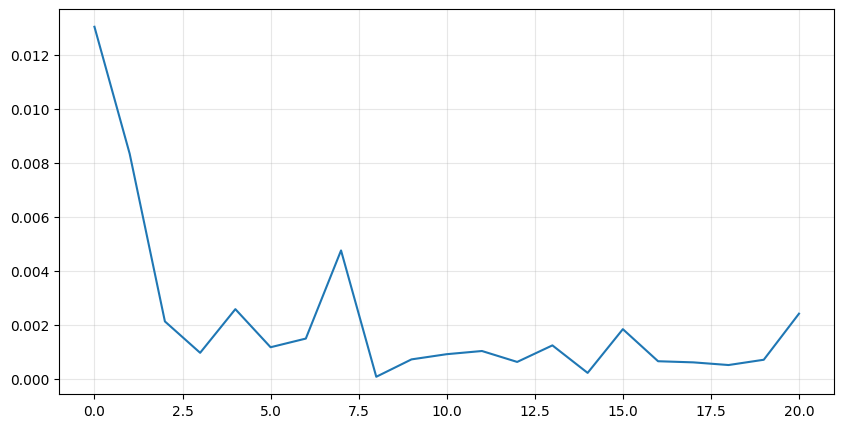

In [4]:
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.plot(ns, u_theorys, 'o-', label='Theory')
plt.plot(ns, u_nums, 's-', label='Numerical')
plt.xlabel('Index')
plt.ylabel('Value')
plt.title('Theory vs Numerical')
plt.legend()

# Plot differences
plt.subplot(1,2,2)
plt.plot(differences, 'o-r')
plt.xlabel('N')
plt.ylabel('Difference (Numerical - Theory)')
plt.title('Differences')
plt.axhline(0, color='gray', linestyle='--')
plt.tight_layout()
plt.show()
plt.figure(figsize=(10,5))
plt.plot(differences)
plt.grid(alpha=0.3)
plt.show()